In [1]:
import matplotlib.pyplot as plt
import os
import re

os.makedirs('../reports/charts', exist_ok=True)
if not hasattr(plt, '_original_show'):
    plt._original_show = plt.show
    plt._plot_counter = 1

    def _custom_show(*args, **kwargs):
        title = plt.gca().get_title()
        if title:
            clean_title = re.sub(r'[^\w\-_\. ]', '_', title).strip().replace(' ', '_')
            filename = f'../reports/charts/{clean_title}_{plt._plot_counter}.png'
        else:
            filename = f'../reports/charts/05_indices_figure_{plt._plot_counter}.png'
            
        try:
            plt.savefig(filename, bbox_inches='tight')
            print(f"Saved chart to {filename}")
        except Exception as e:
            print(f"Warning: Could not save figure {filename}: {e}")
            
        plt._plot_counter += 1
        plt._original_show(*args, **kwargs)

    plt.show = _custom_show


# 6.0 Quantitative Indices Construction

**Reference files used:**
- `../data/raw/state_crosswalk.csv` — canonical state codes, valid-from/to years, bifurcation history  
- `../data/raw/state_name_audit.csv` — raw state names identified during the audit pass  
- `../data/raw/state_name_variants.csv` — variant → canonical name lookup (also used in cleanup notebook)

**Filtered inputs expected:**
```
../data/interim/clean_election_results_1951_2019.csv
../data/interim/clean_loksabha_1962_2019.csv
../data/interim/clean_election_results_2024.csv
../data/interim/clean_ref_party_master.csv
../data/interim/features_dataset.csv
```

---
## Imports & Data Loading

In [2]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

In [3]:
# ─── Reference files ────────────────────────────────────────────────────────
state_crosswalk     = pd.read_csv('../data/raw/state_crosswalk.csv')
state_name_audit    = pd.read_csv('../data/raw/state_name_audit.csv')
state_name_variants = pd.read_csv('../data/raw/state_name_variants.csv')

# ─── Cleaned election datasets (output of cleanup notebook) ─────────────────
df_1951_2019 = pd.read_csv('../data/interim/clean_election_results_1951_2019.csv')
df_loksabha  = pd.read_csv('../data/interim/clean_loksabha_1962_2019.csv')
df_2024      = pd.read_csv('../data/interim/clean_election_results_2024.csv')
df_party     = pd.read_csv('../data/interim/clean_ref_party_master.csv')
df_features  = pd.read_csv('../data/interim/features_dataset.csv')

print('Loaded datasets:')
print(f'  clean_election_results_1951_2019 : {df_1951_2019.shape}')
print(f'  clean_loksabha_1962_2019         : {df_loksabha.shape}')
print(f'  clean_election_results_2024      : {df_2024.shape}')
print(f'  clean_ref_party_master           : {df_party.shape}')
print(f'  df_features                      : {df_features.shape}')

Loaded datasets:
  clean_election_results_1951_2019 : (89840, 19)
  clean_loksabha_1962_2019         : (8047, 15)
  clean_election_results_2024      : (8902, 16)
  clean_ref_party_master           : (10153, 27)
  df_features                      : (89840, 30)


## 6.1 Party Dominance Index (PDI)

The Party Dominance Index measures the degree of control the strongest party holds in a given electoral unit. A common formulation uses the vote share of the largest party or the margin of victory. Here, we define it as the absolute vote share of the winning party in a constituency.
<br>
Mathematical Formula:$$PDI = \max_{i} (v_{i, t})$$(where $v_{i,t}$ is the vote share of party $i$ in election $t$)

In [4]:
import pandas as pd

# Calculate PDI by finding the maximum vote share in each constituency per election
pdi_df = df_features.groupby(['state_canonical', 'constitution', 'election_year_clean'])['vote_share_pct'].max().reset_index()
pdi_df.rename(columns={'vote_share_pct': 'PDI'}, inplace=True)

# Merge back into the features dataset
df_features = df_features.merge(pdi_df, on=['state_canonical', 'constitution', 'election_year_clean'], how='left')
df_features.head()

,Unnamed: 0,id,state,constitution,election_year,candidate,gender,party,age,category,...,vote_swing,vote_share_lag2,is_winner,is_incumbent,vote_share_frac,vote_share_frac_sq,fragmentation_index,alliance,coalition_strength_score,PDI
0,0,8256.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1991 (10th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,...,NaN,NaN,0,0,0.0485,0.002352,2.216692,NDA,4.85,50.39
1,1,12395.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1996 (11th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,...,19.40,NaN,0,0,0.2425,0.058806,2.389941,NDA,24.25,58.22
2,2,4665.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1998 (12th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,...,11.28,4.85,0,0,0.3553,0.126238,3.328441,NDA,35.53,35.91
3,3,4594.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1999 (13th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,...,17.21,24.25,1,0,0.5274,0.278151,2.147515,NDA,52.74,52.74
4,4,5307.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,2004 (14th LOK SABHA),BISHNU PADA RAY,M,BJP,54.0,NaN,...,-16.79,35.53,0,1,0.3595,0.129240,2.265026,NDA,35.95,55.77


## 6.2 Electoral Volatility (Pedersen Index)

The Pedersen Index measures the net change in the vote shares of all parties from one election to the next, capturing the aggregate volatility of the party system. <br>Mathematical Formula:$$V = \frac{1}{2} \sum_{i=1}^{n} |v_{i,t} - v_{i,t-1}|$$(where $v_{i,t}$ is the vote share of party $i$ at time $t$, and $v_{i,t-1}$ is its share in the previous election)

In [5]:
# df_features already contains 'vote_swing' (v_t - v_t-1)
df_features['abs_vote_swing'] = df_features['vote_swing'].abs()

# Calculate Pedersen Index per constituency per election year
pedersen_df = df_features.groupby(['state_canonical', 'constitution', 'election_year_clean'])['abs_vote_swing'].sum().reset_index()
pedersen_df['pedersen_index'] = pedersen_df['abs_vote_swing'] / 2

# Merge back into features
df_features = df_features.merge(pedersen_df[['state_canonical', 'constitution', 'election_year_clean', 'pedersen_index']], 
                                on=['state_canonical', 'constitution', 'election_year_clean'], how='left')

pedersen_df.head()

,state_canonical,constitution,election_year_clean,abs_vote_swing,pedersen_index
0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1971,20.00,10.000
1,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1977,42.03,21.015
2,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1980,41.41,20.705
3,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1984,16.55,8.275
4,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1989,30.78,15.390


In [6]:
df_features.head()

,Unnamed: 0,id,state,constitution,election_year,candidate,gender,party,age,category,...,is_winner,is_incumbent,vote_share_frac,vote_share_frac_sq,fragmentation_index,alliance,coalition_strength_score,PDI,abs_vote_swing,pedersen_index
0,0,8256.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1991 (10th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,...,0,0,0.0485,0.002352,2.216692,NDA,4.85,50.39,NaN,8.640
1,1,12395.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1996 (11th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,...,0,0,0.2425,0.058806,2.389941,NDA,24.25,58.22,19.40,29.075
2,2,4665.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1998 (12th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,...,0,0,0.3553,0.126238,3.328441,NDA,35.53,35.91,11.28,23.395
3,3,4594.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,1999 (13th LOK SABHA),BISHNU PADA RAY,M,BJP,NaN,NaN,...,1,0,0.5274,0.278151,2.147515,NDA,52.74,52.74,17.21,15.430
4,4,5307.0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN & NICOBAR ISLANDS,2004 (14th LOK SABHA),BISHNU PADA RAY,M,BJP,54.0,NaN,...,0,1,0.3595,0.129240,2.265026,NDA,35.95,55.77,16.79,17.195


## 6.3 Effective Number of Parties (ENP)

The Laakso-Taagepera index estimates the number of competitive parties in a system, weighting them by their relative size (squared vote shares). <br>
Mathematical Formula:$$N = \frac{1}{\sum_{i=1}^{n} p_i^2}$$(where $p_i$ is the fractional vote share of party $i$)

Saved chart to ../reports/charts/Average_Effective_Number_of_Parties__ENP__per_Constituency_Over_Time_1.png


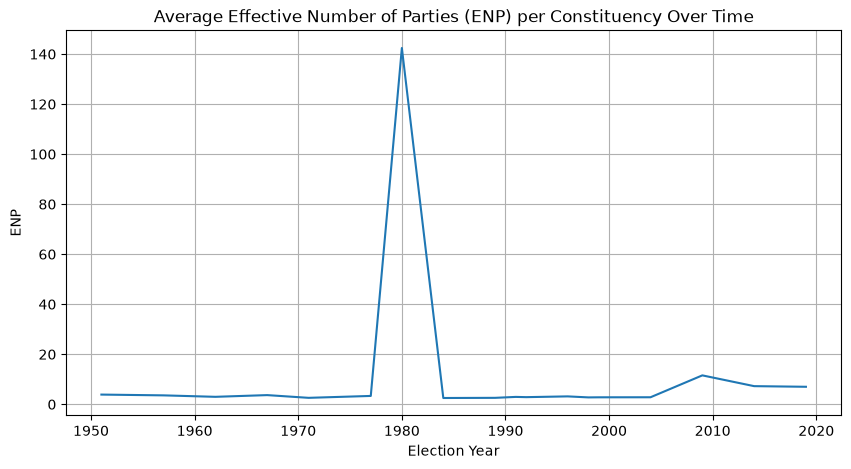

In [7]:
# Compute ENP (already partially in df_features as fragmentation_index, but here is the formal aggregation)
# df_features has 'vote_share_frac_sq'
enp_national = df_features.groupby('election_year_clean')['vote_share_frac_sq'].sum().reset_index()
enp_national['national_ENP'] = 1 / enp_national['vote_share_frac_sq']

# Visualize ENP over time
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_features, x='election_year_clean', y='fragmentation_index', estimator='mean', ci=None)
plt.title('Average Effective Number of Parties (ENP) per Constituency Over Time')
plt.ylabel('ENP')
plt.xlabel('Election Year')
plt.grid(True)
plt.show()

## 6.4 Other indices

### A. Gallagher Index (Seat-Vote Disproportionality)

Measures the disproportionality between the percentage of votes a party receives nationally and the percentage of legislative seats it secures. <br>Mathematical Formula:$$G = \sqrt{\frac{1}{2} \sum_{i=1}^{n} (V_i - S_i)^2}$$(where $V_i$ is the vote share % and $S_i$ is the seat share % of party $i$)

In [8]:
# Calculate national seats and votes per party per year using df_features
national_totals = df_features.groupby('election_year_clean').agg(
    total_seats=('is_winner', 'sum'),
    total_votes=('votes_received', 'sum')
).reset_index()

party_totals = df_features.groupby(['election_year_clean', 'party']).agg(
    party_seats=('is_winner', 'sum'),
    party_votes=('votes_received', 'sum')
).reset_index()

# Merge and calculate shares
gallagher_df = party_totals.merge(national_totals, on='election_year_clean')
gallagher_df['S_i'] = (gallagher_df['party_seats'] / gallagher_df['total_seats']) * 100
gallagher_df['V_i'] = (gallagher_df['party_votes'] / gallagher_df['total_votes']) * 100

# Calculate index
gallagher_df['diff_sq'] = (gallagher_df['V_i'] - gallagher_df['S_i']) ** 2
g_index = gallagher_df.groupby('election_year_clean')['diff_sq'].sum().apply(lambda x: np.sqrt(x / 2)).reset_index(name='gallagher_index')

In [9]:
gallagher_df.head()

,election_year_clean,party,party_seats,party_votes,total_seats,total_votes,S_i,V_i,diff_sq
0,1951,AMN,0,22083.0,487,105950083.0,0.000000,0.020843,0.000434
1,1951,APP,0,36851.0,487,105950083.0,0.000000,0.034781,0.001210
2,1951,BJS,3,3246361.0,487,105950083.0,0.616016,3.064048,5.992857
3,1951,BPI,0,25792.0,487,105950083.0,0.000000,0.024344,0.000593
4,1951,CNSPJP,1,236094.0,487,105950083.0,0.205339,0.222835,0.000306


In [10]:
g_index.head()

,election_year_clean,gallagher_index
0,1951,22.566776
1,1957,20.394656
2,1962,21.727477
3,1967,10.485249
4,1971,18.656656


### B. Loosemore-Hanby Index

An alternative measure of electoral disproportionality using the absolute difference between seat and vote shares instead of squared differences. <br> Mathematical Formula:$$D = \frac{1}{2} \sum_{i=1}^{n} |V_i - S_i|$$

In [11]:
# Using the gallagher_df generated above
gallagher_df['abs_diff'] = (gallagher_df['V_i'] - gallagher_df['S_i']).abs()
lh_index = gallagher_df.groupby('election_year_clean')['abs_diff'].sum().apply(lambda x: x / 2).reset_index(name='loosemore_hanby_index')
lh_index.head()

,election_year_clean,loosemore_hanby_index
0,1951,30.438708
1,1957,26.918785
2,1962,29.797670
3,1967,14.907956
4,1971,26.453849


Saved chart to ../reports/charts/Electoral_Disproportionality_in_India__1951-2024__2.png


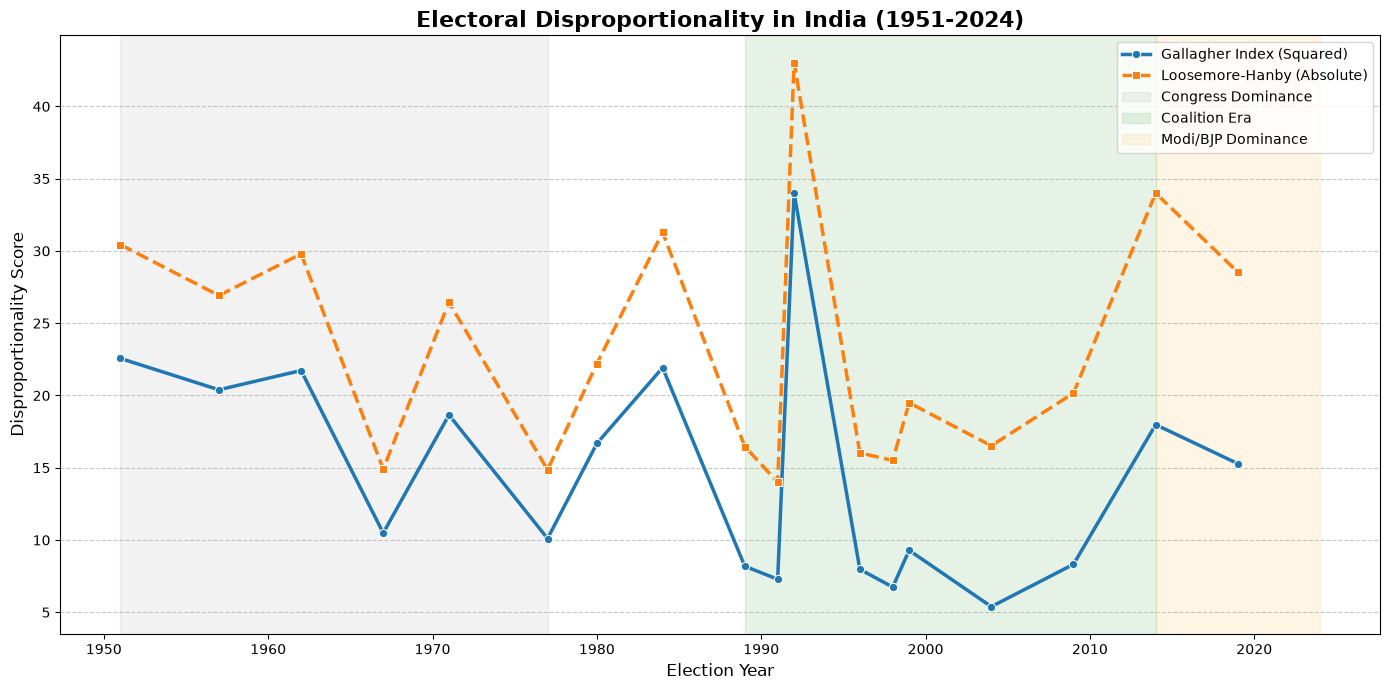

In [12]:
df_macro = pd.merge(g_index, lh_index, on='election_year_clean')

plt.figure(figsize=(14, 7))

# Plot both indices
sns.lineplot(data=df_macro, x='election_year_clean', y='gallagher_index', 
             label='Gallagher Index (Squared)', color='#1f77b4', linewidth=2.5, marker='o')
sns.lineplot(data=df_macro, x='election_year_clean', y='loosemore_hanby_index', 
             label='Loosemore-Hanby (Absolute)', color='#ff7f0e', linewidth=2.5, marker='s', linestyle='--')

# Add shaded eras for context
plt.axvspan(1951, 1977, color='grey', alpha=0.1, label='Congress Dominance')
plt.axvspan(1989, 2014, color='green', alpha=0.1, label='Coalition Era')
plt.axvspan(2014, 2024, color='orange', alpha=0.1, label='Modi/BJP Dominance')

plt.title('Electoral Disproportionality in India (1951-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Election Year', fontsize=12)
plt.ylabel('Disproportionality Score', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### C. Coalition Complexity Index

A simple count of the effective number of distinct political parties operating within a predefined governing alliance, representing coalition fragility. <br>
Mathematical Formula:$$C_{A,t} = |\{P_i \in A_{t}\}|$$(where $C$ is the count of unique parties $P_i$ within alliance $A$ at time $t$)

In [13]:
# Count unique parties per alliance per year
coalition_complexity = df_features[df_features['is_winner'] == 1].groupby(['election_year_clean', 'alliance'])['party'].nunique().reset_index(name='coalition_party_count')
coalition_complexity.head()

,election_year_clean,alliance,coalition_party_count
0,1951,UPA,1
1,1951,Unaffiliated,22
2,1957,UPA,1
3,1957,Unaffiliated,13
4,1962,UPA,2


Saved chart to ../reports/charts/Coalition_Complexity__Number_of_Parties_Winning_Seats_per_Alliance_3.png


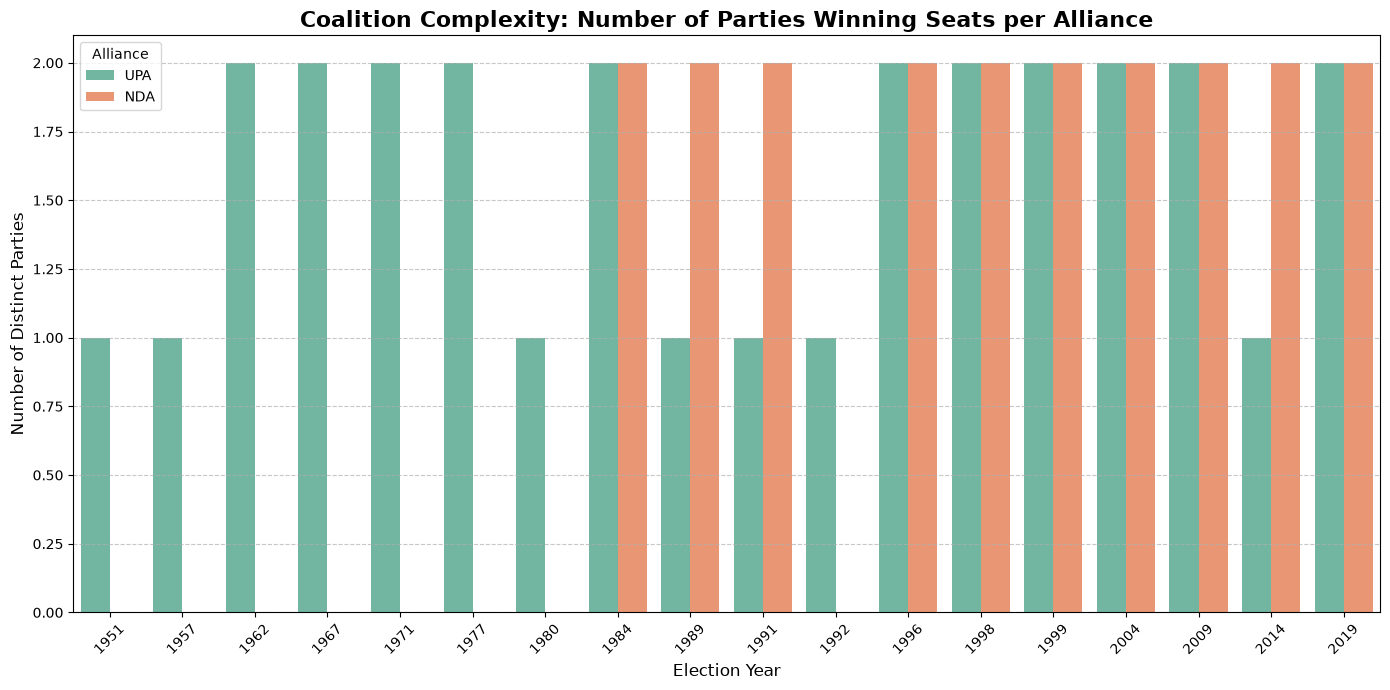

In [14]:
# Filter for winning candidates only to see who is actually going to parliament
winners_df = df_features[df_features['is_winner'] == 1]

# Exclude 'Unaffiliated' or 'Independent' to focus strictly on formal coalitions
coalition_winners = winners_df[~winners_df['alliance'].isin(['Unaffiliated', 'IND'])]

# Count unique parties per alliance per election year
complexity_df = coalition_winners.groupby(['election_year_clean', 'alliance'])['party'].nunique().reset_index()
complexity_df.rename(columns={'party': 'party_count'}, inplace=True)

plt.figure(figsize=(14, 7))

# Create a bar plot showing the complexity of alliances
sns.barplot(data=complexity_df, x='election_year_clean', y='party_count', hue='alliance', palette='Set2')

plt.title('Coalition Complexity: Number of Parties Winning Seats per Alliance', fontsize=16, fontweight='bold')
plt.xlabel('Election Year', fontsize=12)
plt.ylabel('Number of Distinct Parties', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Alliance', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()